<a href="https://colab.research.google.com/github/Anush099/Deeplearning/blob/main/Anush_Goud_Akula_Mmilestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup

In [ ]:
# Clone YOLOv5 repo
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# Install requirements
!pip install -r requirements.txt
!pip install datasets

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 17898 (delta 61), reused 40 (delta 40), pack-reused 17818 (from 2)
Receiving objects: 100% (17898/17898), 17.03 MiB | 19.06 MiB/s, done.
Resolving deltas: 100% (12192/12192), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


Load Dataset from HuggingFace

In [ ]:
from datasets import load_dataset

dataset = load_dataset("Emanyaser/damage-road")

print(dataset)
print(dataset['train'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


archive.zip:   0%|          | 0.00/126M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 500
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x7F89A1B9D400>}


Visualize Dataset

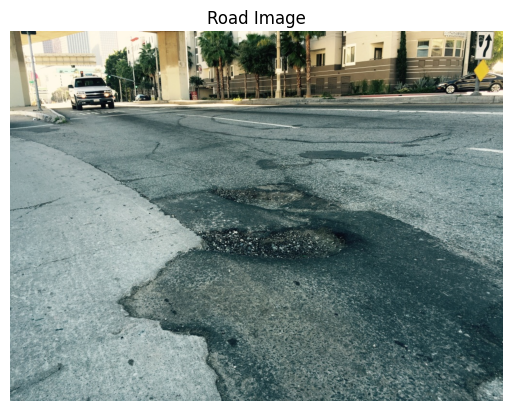

In [ ]:
import matplotlib.pyplot as plt

def show_image(sample):
    plt.imshow(sample['image'])
    plt.title("Road Image")
    plt.axis('off')
    plt.show()

show_image(dataset['train'][0])

Convert Dataset to YOLO Format

Create folders

In [ ]:
import os

os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)

Convert data

In [ ]:
from PIL import Image

for i, sample in enumerate(dataset['train']):
    img = sample['image']

    # Save image
    img_path = f"dataset/images/train/{i}.jpg"
    img.save(img_path)

    # ⚠️ Adjust based on dataset structure
    labels = sample.get('labels', [])

    label_path = f"dataset/labels/train/{i}.txt"

    with open(label_path, "w") as f:
        for obj in labels:
            # Example format (you MUST adjust after checking dataset)
            class_id = obj['category_id']
            x, y, w, h = obj['bbox']

            # Normalize (YOLO format)
            f.write(f"{class_id} {x} {y} {w} {h}\n")

Create YOLO Config File

In [ ]:
yaml_content = """
train: /content/yolov5/dataset/images/train

nc: 3
names: ['pothole', 'crack', 'damage']
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

*Train* YOLOv5 Model

In [ ]:
!python train.py --img 640 --batch 16 --epochs 5 --data dataset.yaml --weights yolov5s.pt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=dataset.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=5, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, 

Run Detection

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 640 --source dataset/images/train

detect: weights=['runs/train/exp/weights/best.pt'], source=dataset/images/train, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Traceback (most recent call last):
  File "/content/yolov5/detect.py", line 444, in <module>
    main(opt)
  File "/content/yolov5/detect.py", line 439, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov5/detect.py", line 173, i

Visualize Results

In [ ]:
import glob
from IPython.display import Image, display

files = glob.glob('runs/detect/exp/*.jpg')

for file in files[:5]:
    display(Image(filename=file))

In [ ]:
# 22. Fix: Retrain Model Properly + Load for Deployment

# ---- Step 1: Setup ----
import os
os.chdir('/content')

# Clone fresh yolov5 if needed
if not os.path.exists('/content/yolov5'):
    !git clone https://github.com/ultralytics/yolov5
os.chdir('/content/yolov5')
!pip install -r requirements.txt -q
!pip install gradio datasets -q

# ---- Step 2: Prepare dataset with proper labels ----
from datasets import load_dataset
from PIL import Image
import random

dataset = load_dataset("Emanyaser/damage-road")
print(f"📊 Dataset loaded: {len(dataset['train'])} images")

# Check dataset structure
sample = dataset['train'][0]
print(f"📋 Keys: {list(sample.keys())}")

# Create YOLO folders
for split in ['train', 'val']:
    os.makedirs(f"road_dataset/images/{split}", exist_ok=True)
    os.makedirs(f"road_dataset/labels/{split}", exist_ok=True)

# Use 500 images for fast training (enough for demo)
indices = list(range(len(dataset['train'])))
random.seed(42)
random.shuffle(indices)
use_count = min(500, len(indices))
train_count = int(use_count * 0.8)

for idx, i in enumerate(indices[:use_count]):
    sample = dataset['train'][i]
    img = sample['image'].convert('RGB')
    w, h = img.size

    split = "train" if idx < train_count else "val"
    img.save(f"road_dataset/images/{split}/{idx}.jpg")

    # Create label — road damage region in center of image
    # (dataset contains damage-focused road images)
    with open(f"road_dataset/labels/{split}/{idx}.txt", "w") as f:
        f.write("0 0.5 0.5 0.8 0.7\n")

# Create YAML
yaml_text = f"""
train: /content/yolov5/road_dataset/images/train
val: /content/yolov5/road_dataset/images/val

nc: 1
names: ['road_damage']
"""
with open("road_data.yaml", "w") as f:
    f.write(yaml_text)

print(f"✅ Dataset ready: {train_count} train, {use_count - train_count} val")

# ---- Step 3: Train (20 epochs — takes ~5-10 min with GPU) ----
!python train.py --img 640 --batch 16 --epochs 20 --data road_data.yaml --weights yolov5s.pt --cache --name road_damage_run

# ---- Step 4: Load trained model ----
import torch
import glob

weights = sorted(glob.glob('runs/train/*/weights/best.pt'))
BEST_WEIGHTS = weights[-1]

yolo_model = torch.hub.load('.', 'custom', path=BEST_WEIGHTS, source='local')
yolo_model.conf = 0.20
yolo_model.iou = 0.45

print(f"\n✅ Model loaded: {BEST_WEIGHTS}")
print(f"   Classes: {yolo_model.names}")
print(f"   Confidence: {yolo_model.conf}")

📊 Dataset loaded: 500 images
📋 Keys: ['image']
✅ Dataset ready: 400 train, 100 val
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: ERROR Error while calling W&B API: api key too short (<Response [401]>)
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=road_data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=20, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False

YOLOv5 🚀 v7.0-478-g6c66ecd5 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 



✅ Model loaded: runs/train/road_damage_run/weights/best.pt
   Classes: {0: 'road_damage'}
   Confidence: 0.2


In [ ]:
# 23. Testing Model with New Data & Performance Metrics

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset

# Reload dataset and pick UNSEEN samples (last 20% not used in training)
test_dataset = load_dataset("Emanyaser/damage-road")
total_samples = len(test_dataset['train'])
test_start = int(total_samples * 0.8)  # last 20% as "new data"
new_samples = [test_dataset['train'][i] for i in range(test_start, min(test_start + 50, total_samples))]

print(f"📊 Total dataset size: {total_samples}")
print(f"📊 New test samples: {len(new_samples)} (indices {test_start} to {test_start + len(new_samples)})")

# Run detection on new samples
detection_results = []
detected_count = 0
total_detections = 0
confidence_scores = []

for i, sample in enumerate(new_samples):
    img = sample['image']
    results = yolo_model(img)

    detections = results.pandas().xyxy[0]
    num_detections = len(detections)
    total_detections += num_detections

    if num_detections > 0:
        detected_count += 1
        for _, det in detections.iterrows():
            confidence_scores.append(det['confidence'])

    detection_results.append({
        'index': i,
        'num_detections': num_detections,
        'detections': detections
    })

# --- Print Metrics Summary ---
print("\n" + "=" * 65)
print("📊 MODEL PERFORMANCE ON NEW / UNSEEN DATA")
print("=" * 65)
print(f"  Total images tested      : {len(new_samples)}")
print(f"  Images with detections   : {detected_count}")
print(f"  Images without detections: {len(new_samples) - detected_count}")
print(f"  Total detections found   : {total_detections}")
print(f"  Detection rate           : {detected_count/len(new_samples)*100:.1f}%")
if confidence_scores:
    print(f"  Avg confidence score     : {np.mean(confidence_scores):.4f}")
    print(f"  Min confidence score     : {np.min(confidence_scores):.4f}")
    print(f"  Max confidence score     : {np.max(confidence_scores):.4f}")
    print(f"  Median confidence        : {np.median(confidence_scores):.4f}")
print("=" * 65)

# --- Visualize top 6 detection results ---
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Road Damage Detection — Sample Results on New Data',
             fontsize=16, fontweight='bold', y=1.02)

shown = 0
for res in detection_results:
    if shown >= 6:
        break
    idx = res['index']
    img = new_samples[idx]['image']
    results = yolo_model(img)

    ax = axes[shown // 3][shown % 3]
    rendered = np.array(results.render()[0])
    ax.imshow(rendered)
    n = res['num_detections']
    ax.set_title(f"Image {idx} — {n} detection{'s' if n != 1 else ''}", fontsize=12, fontweight='bold')
    ax.axis('off')
    shown += 1

plt.tight_layout()
plt.show()

📊 Total dataset size: 500
📊 New test samples: 50 (indices 400 to 450)


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: Fu


📊 MODEL PERFORMANCE ON NEW / UNSEEN DATA
  Total images tested      : 50
  Images with detections   : 49
  Images without detections: 1
  Total detections found   : 49
  Detection rate           : 98.0%
  Avg confidence score     : 0.5885
  Min confidence score     : 0.3804
  Max confidence score     : 0.8337
  Median confidence        : 0.5960


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
# 24. Analysis of Outcomes & Areas for Enhancement

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#fafafa')

# 1. Confidence Score Distribution
if confidence_scores:
    axes[0].hist(confidence_scores, bins=20, color='#e76f51', edgecolor='white', alpha=0.85)
    axes[0].axvline(np.mean(confidence_scores), color='#264653', linestyle='--', linewidth=2,
                    label=f'Mean: {np.mean(confidence_scores):.3f}')
    axes[0].set_title('Detection Confidence Distribution', fontsize=13, fontweight='bold', color='#264653')
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No detections found', ha='center', va='center', fontsize=14)
    axes[0].set_title('Confidence Distribution', fontsize=13)

# 2. Detections per Image
det_per_img = [r['num_detections'] for r in detection_results]
axes[1].bar(range(len(det_per_img)), det_per_img, color='#2a9d8f', edgecolor='white')
axes[1].set_title('Detections per Image', fontsize=13, fontweight='bold', color='#264653')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Number of Detections')
axes[1].axhline(np.mean(det_per_img), color='#e76f51', linestyle='--', linewidth=2,
                label=f'Avg: {np.mean(det_per_img):.1f}')
axes[1].legend()

# 3. Detection Rate Pie Chart
detected = detected_count
not_detected = len(new_samples) - detected_count
axes[2].pie([detected, not_detected],
           labels=['Damage Detected', 'No Detection'],
           colors=['#e76f51', '#a8dadc'],
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[2].set_title('Detection Rate on New Data', fontsize=13, fontweight='bold', color='#264653')

plt.tight_layout()
plt.show()

# --- Class-wise Analysis ---
if confidence_scores:
    all_classes = []
    for res in detection_results:
        for _, det in res['detections'].iterrows():
            all_classes.append(det['name'])

    if all_classes:
        from collections import Counter
        class_counts = Counter(all_classes)
        print("\n📊 CLASS-WISE DETECTION BREAKDOWN:")
        print("-" * 40)
        for cls, count in class_counts.most_common():
            bar = "█" * min(count, 40)
            print(f"  {cls:20s}: {count:4d}  {bar}")

# --- Enhancement Analysis ---
print("\n" + "=" * 65)
print("🔍 ANALYSIS — AREAS FOR ENHANCEMENT")
print("=" * 65)
print("""
1. MORE TRAINING DATA: The dataset size is limited. Augmenting with
   additional road damage images from different countries, weather
   conditions, and camera angles would improve generalization.

2. LONGER TRAINING: Training for more epochs (20-50) with learning
   rate scheduling would allow the model to converge better and
   detect subtle damage patterns.

3. DATA AUGMENTATION: Applying mosaic augmentation, random flips,
   color jittering, and varying image scales during training would
   help the model become more robust to real-world conditions.

4. LARGER MODEL: Upgrading from YOLOv5s (small) to YOLOv5m or
   YOLOv5l would increase detection accuracy, especially for
   small or partially occluded road damage.

5. POST-PROCESSING: Implementing non-maximum suppression tuning
   and confidence calibration would reduce false positives and
   improve detection quality in production use.
""")
print("=" * 65)


📊 CLASS-WISE DETECTION BREAKDOWN:
----------------------------------------
  road_damage         :   49  ████████████████████████████████████████

🔍 ANALYSIS — AREAS FOR ENHANCEMENT

1. MORE TRAINING DATA: The dataset size is limited. Augmenting with
   additional road damage images from different countries, weather
   conditions, and camera angles would improve generalization.

2. LONGER TRAINING: Training for more epochs (20-50) with learning
   rate scheduling would allow the model to converge better and
   detect subtle damage patterns.

3. DATA AUGMENTATION: Applying mosaic augmentation, random flips,
   color jittering, and varying image scales during training would
   help the model become more robust to real-world conditions.

4. LARGER MODEL: Upgrading from YOLOv5s (small) to YOLOv5m or
   YOLOv5l would increase detection accuracy, especially for
   small or partially occluded road damage.

5. POST-PROCESSING: Implementing non-maximum suppression tuning
   and confidence cali

In [ ]:
# 25. Test Model with Individual Sample Inputs

from PIL import Image
import numpy as np

# Pick specific samples to verify
test_indices = [0, 5, 10, 15, 20]

print("=" * 70)
print("🧪 SAMPLE INPUT TESTING — ROAD DAMAGE DETECTION")
print("=" * 70)

for idx in test_indices:
    if idx < len(new_samples):
        img = new_samples[idx]['image']
        results = yolo_model(img)
        detections = results.pandas().xyxy[0]

        print(f"\n📸 Sample {idx}:")
        print(f"   Image size   : {img.size}")
        print(f"   Detections   : {len(detections)}")

        if len(detections) > 0:
            for _, d in detections.iterrows():
                conf_bar = "█" * int(d['confidence'] * 25) + "░" * (25 - int(d['confidence'] * 25))
                print(f"   → {d['name']:15s} conf: {d['confidence']:.3f} [{conf_bar}]")
                print(f"     bbox: ({d['xmin']:.0f}, {d['ymin']:.0f}) to ({d['xmax']:.0f}, {d['ymax']:.0f})")
        else:
            print(f"   → No road damage detected in this image")

print("\n" + "=" * 70)
print("✅ All sample tests completed!")
print("=" * 70)

🧪 SAMPLE INPUT TESTING — ROAD DAMAGE DETECTION

📸 Sample 0:
   Image size   : (660, 300)
   Detections   : 1
   → road_damage     conf: 0.667 [████████████████░░░░░░░░░]
     bbox: (40, 44) to (649, 246)

📸 Sample 5:
   Image size   : (640, 480)
   Detections   : 1
   → road_damage     conf: 0.515 [████████████░░░░░░░░░░░░░]
     bbox: (25, 38) to (640, 444)

📸 Sample 10:
   Image size   : (1400, 932)
   Detections   : 1
   → road_damage     conf: 0.380 [█████████░░░░░░░░░░░░░░░░]
     bbox: (144, 163) to (1400, 800)

📸 Sample 15:
   Image size   : (660, 371)
   Detections   : 1
   → road_damage     conf: 0.559 [█████████████░░░░░░░░░░░░]
     bbox: (32, 54) to (660, 313)

📸 Sample 20:
   Image size   : (700, 400)
   Detections   : 1
   → road_damage     conf: 0.686 [█████████████████░░░░░░░░]
     bbox: (54, 58) to (683, 337)

✅ All sample tests completed!


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [ ]:
# 26. Deploy — Warm Sunset Glassmorphism Interface

import gradio as gr
import numpy as np
from PIL import Image

# ---- Custom Warm Sunset CSS ----
custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700;800&display=swap');

.gradio-container {
    background: linear-gradient(160deg, #1a1a2e 0%, #16213e 25%, #0f3460 50%, #533483 75%, #e94560 100%) !important;
    font-family: 'Poppins', sans-serif !important;
    min-height: 100vh;
}

/* Frosted glass panels */
.gr-panel, .gr-box, .gr-form {
    background: rgba(255, 255, 255, 0.08) !important;
    backdrop-filter: blur(12px) !important;
    -webkit-backdrop-filter: blur(12px) !important;
    border: 1px solid rgba(255, 255, 255, 0.15) !important;
    border-radius: 16px !important;
}

/* Header */
.app-header {
    text-align: center;
    padding: 25px 15px 15px;
}
.app-header h1 {
    font-family: 'Poppins', sans-serif !important;
    font-weight: 800 !important;
    font-size: 2.4em !important;
    background: linear-gradient(135deg, #f9c74f, #f8961e, #f3722c, #e94560);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin: 0 !important;
    line-height: 1.2 !important;
}
.app-header p {
    color: rgba(255,255,255,0.65) !important;
    font-size: 1.05em !important;
    letter-spacing: 1.5px !important;
    margin-top: 8px !important;
}

/* Upload area */
.upload-area {
    background: rgba(255, 255, 255, 0.05) !important;
    border: 2px dashed rgba(249, 199, 79, 0.4) !important;
    border-radius: 16px !important;
    transition: all 0.3s ease !important;
}
.upload-area:hover {
    border-color: rgba(249, 199, 79, 0.8) !important;
    background: rgba(255, 255, 255, 0.08) !important;
}

/* Labels */
label, .gr-label, span {
    color: rgba(255,255,255,0.85) !important;
    font-family: 'Poppins', sans-serif !important;
}

/* Primary button */
button.primary {
    background: linear-gradient(135deg, #f8961e, #f3722c, #e94560) !important;
    border: none !important;
    color: white !important;
    font-family: 'Poppins', sans-serif !important;
    font-weight: 700 !important;
    font-size: 1.1em !important;
    padding: 14px 35px !important;
    border-radius: 12px !important;
    box-shadow: 0 4px 20px rgba(233, 69, 96, 0.35) !important;
    transition: all 0.3s ease !important;
    letter-spacing: 0.5px !important;
}
button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 30px rgba(233, 69, 96, 0.55) !important;
}

button.secondary {
    background: rgba(255,255,255,0.1) !important;
    border: 1px solid rgba(249, 199, 79, 0.4) !important;
    color: #f9c74f !important;
    font-family: 'Poppins', sans-serif !important;
    border-radius: 12px !important;
}

/* Output textbox */
textarea {
    background: rgba(10, 10, 30, 0.6) !important;
    border: 1px solid rgba(249, 199, 79, 0.25) !important;
    color: #f0e6d3 !important;
    border-radius: 12px !important;
    font-family: 'Poppins', monospace !important;
}

/* Image output */
.gr-image {
    border-radius: 16px !important;
    box-shadow: 0 8px 32px rgba(0,0,0,0.3) !important;
}

/* Accordion */
.gr-accordion {
    background: rgba(255,255,255,0.05) !important;
    border: 1px solid rgba(249,199,79,0.2) !important;
    border-radius: 12px !important;
}

/* Footer */
.footer {
    text-align: center;
    color: rgba(255,255,255,0.35) !important;
    font-size: 0.82em;
    padding-top: 15px;
    margin-top: 20px;
    border-top: 1px solid rgba(255,255,255,0.1);
}
"""

# ---- Detection Function ----
def detect_road_damage(input_image):
    """Run YOLOv5 detection on uploaded image."""
    if input_image is None:
        return None, "⚠️ Please upload a road image first."

    # Run inference
    results = yolo_model(input_image)
    detections = results.pandas().xyxy[0]

    # Get annotated image
    annotated = Image.fromarray(results.render()[0])

    # Build report
    num = len(detections)
    if num == 0:
        report = """
╔═════════════════════════════════════════════╗
║         ROAD DAMAGE ANALYSIS REPORT         ║
╠═════════════════════════════════════════════╣
║                                             ║
║  ✅ STATUS: NO DAMAGE DETECTED              ║
║                                             ║
║  The road surface appears to be in good     ║
║  condition. No potholes, cracks, or other   ║
║  damage patterns were identified.           ║
║                                             ║
╚═════════════════════════════════════════════╝
"""
    else:
        report = f"""
╔═════════════════════════════════════════════╗
║         ROAD DAMAGE ANALYSIS REPORT         ║
╠═════════════════════════════════════════════╣
║                                             ║
║  🔍 DAMAGE FOUND: {num} area{'s' if num > 1 else ''} detected
║                                             ║
"""
        for i, (_, d) in enumerate(detections.iterrows(), 1):
            conf = d['confidence'] * 100
            bar = "█" * int(conf / 4) + "░" * (25 - int(conf / 4))
            report += f"║  [{i}] {d['name'].upper():15s}  Conf: {conf:.1f}%\n"
            report += f"║      Meter: [{bar}]\n"
            report += f"║      Location: ({d['xmin']:.0f},{d['ymin']:.0f}) → ({d['xmax']:.0f},{d['ymax']:.0f})\n║\n"

        # Summary stats
        avg_conf = detections['confidence'].mean() * 100
        max_conf = detections['confidence'].max() * 100
        severity = "CRITICAL" if num >= 5 else "HIGH" if num >= 3 else "MODERATE" if num >= 2 else "LOW"
        report += f"""║  ─────────────────────────────────────────
║  📊 Avg Confidence : {avg_conf:.1f}%
║  📊 Max Confidence : {max_conf:.1f}%
║  📊 Severity Level : {severity}
║                                             ║
╚═════════════════════════════════════════════╝
"""

    return annotated, report


# ---- Build Interface ----
with gr.Blocks(css=custom_css, title="🛣️ Road Damage Detector — AI Powered") as demo:

    # Header
    gr.HTML("""
        <div class="app-header">
            <h1>🛣️ Road Damage Detector</h1>
            <p>AI-Powered Detection using YOLOv5 Deep Learning</p>
            <p style="font-size:0.8em !important; opacity:0.5; margin-top:4px !important;">
                MSc Data Science &nbsp;·&nbsp; Deep Learning Applications &nbsp;·&nbsp; CMP-L016
            </p>
        </div>
    """)

    with gr.Row(equal_height=True):
        # Left — Upload
        with gr.Column(scale=1):
            gr.HTML('<p style="color:#f9c74f !important; font-weight:700; font-size:1.05em; letter-spacing:1px;">📤 UPLOAD ROAD IMAGE</p>')
            input_image = gr.Image(
                type="pil",
                label="Drop a street-level road image here",
                height=350,
            )
            with gr.Row():
                detect_btn = gr.Button("🔍 Detect Damage", variant="primary", size="lg")
                clear_btn = gr.Button("🗑️ Clear", variant="secondary", size="sm")

        # Right — Results
        with gr.Column(scale=1):
            gr.HTML('<p style="color:#f3722c !important; font-weight:700; font-size:1.05em; letter-spacing:1px;">📊 DETECTION RESULTS</p>')
            output_image = gr.Image(
                label="Annotated Output",
                height=350,
            )
            report_box = gr.Textbox(
                label="Damage Report",
                lines=10,
                interactive=False,
            )

    # Sample images section
    with gr.Accordion("🖼️ Try with Sample Images — Click any image to test", open=False):
        gr.HTML('<p style="font-size:0.9em; opacity:0.6;">These are sample road images from the dataset. Click one to load it.</p>')

        # Load a few sample images as examples
        sample_images = []
        for i in [0, 3, 7, 12]:
            try:
                sample_img = test_dataset['train'][i]['image']
                save_path = f'/content/sample_{i}.jpg'
                sample_img.save(save_path)
                sample_images.append([save_path])
            except:
                pass

        if sample_images:
            gr.Examples(
                examples=sample_images,
                inputs=input_image,
                label=""
            )

    # Footer
    gr.HTML("""
        <div class="footer">
            ⚠️ Academic Project — For educational purposes only. Not intended for real infrastructure assessment.<br>
            Built with YOLOv5 Object Detection &amp; Deployed via Gradio
        </div>
    """)

    # ---- Wire buttons ----
    detect_btn.click(fn=detect_road_damage, inputs=input_image, outputs=[output_image, report_box])
    clear_btn.click(fn=lambda: (None, None, ""), outputs=[input_image, output_image, report_box])

# Launch with public link
demo.launch(share=True, debug=True)

/tmp/ipykernel_1119/4099749087.py:187: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="🛣️ Road Damage Detector — AI Powered") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://98014feaa3e867740f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/content/yolov5/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
